# Advanced Data Mining for Data-Driven Insights and Predictive Modeling

## Project Deliverable 3: Classification, Clustering, and Pattern Mining

**Course:** 2026 Summer - Advanced Big Data and Data Mining  
**Course Number:** MSCS-634-M20  
**Date:** July 24-26, 2026  
**Dataset:** Credit Card Fraud Detection  
**Dataset Source:** [Credit Card Fraud Detection on Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

**Group Members:**  
Ashish Mahajan  
Murali Krishna Vattikunta  
Sreesh Sattiyamourthy  
Sreeharsha Varma Tinnanuri

### Purpose

This deliverable compares imbalance-aware fraud classifiers, explores unlabeled transaction segments with K-Means, and mines association rules from discretized training patterns.

### Objectives

- Compare class-weighted Logistic Regression and a tuned Decision Tree.
- Evaluate fraud detection with Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, and confusion matrices.
- Select a K-Means solution using inertia, silhouette score, cluster balance, and interpretability.
- Apply FP-Growth to a documented enriched training sample.

### Dataset and Ethical Note

The classification test set remains untouched until final evaluation. `Class` is excluded from clustering inputs and reattached only for external profiling. Association rules describe co-occurrence, not causation, and none of these methods should autonomously accuse a customer of fraud.

### Notebook Roadmap

1. Load, clean, engineer features, and create a stratified split.
2. Train Logistic Regression and tune a Decision Tree.
3. evaluate and visualize both classifiers.
4. evaluate K-Means for `k=2` through `k=6` and profile the selected solution.
5. discretize focused training features and mine fraud-consequent FP-Growth rules.
6. save all rubric-required tables, figures, interpretations, and recommendations.

## 1. Setup, Cleaning, and Classification Features

**Objective:** Apply the same exact-duplicate cleaning rule, create non-destructive time and amount features, and reserve a stratified 20% test partition. Scaling remains inside the Logistic Regression pipeline.

In [1]:
import shutil
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from mlxtend.frequent_patterns import association_rules, fpgrowth
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
PCA_COLUMNS = [f"V{number}" for number in range(1, 29)]
REQUIRED_COLUMNS = ["Time", *PCA_COLUMNS, "Amount", "Class"]

Path("data").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)
Path("images/deliverable_3").mkdir(parents=True, exist_ok=True)

def load_credit_card_data():
    dataset_path = next(
        (path for path in (Path("data/creditcard.csv"), Path("creditcard.csv")) if path.is_file()),
        None,
    )
    if dataset_path is None:
        download_path = Path(kagglehub.dataset_download("mlg-ulb/creditcardfraud"))
        matches = list(download_path.rglob("creditcard.csv"))
        if len(matches) != 1:
            raise FileNotFoundError("Download creditcard.csv from Kaggle and place it in data/.")
        dataset_path = Path("data/creditcard.csv")
        shutil.copy2(matches[0], dataset_path)
    dataframe = pd.read_csv(dataset_path)
    if dataframe.columns.tolist() != REQUIRED_COLUMNS:
        raise ValueError("Dataset columns do not match the approved credit-card dataset.")
    return dataframe, dataset_path

def save_figure(path):
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

raw_df, dataset_path = load_credit_card_data()
clean_df = raw_df.drop_duplicates().reset_index(drop=True)
model_df = clean_df.copy()
model_df["Hour"] = (model_df["Time"] / 3600) % 24
model_df["DayIndex"] = np.floor(model_df["Time"] / 86400).astype(int)
model_df["LogAmount"] = np.log1p(model_df["Amount"])
model_df["HourSin"] = np.sin(2 * np.pi * model_df["Hour"] / 24)
model_df["HourCos"] = np.cos(2 * np.pi * model_df["Hour"] / 24)

classification_features = [
    *PCA_COLUMNS,
    "LogAmount",
    "HourSin",
    "HourCos",
    "DayIndex",
]
X = model_df[classification_features]
y = model_df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "Partition": ["Training", "Test"],
    "Rows": [len(X_train), len(X_test)],
    "Legitimate": [(y_train == 0).sum(), (y_test == 0).sum()],
    "Fraud": [(y_train == 1).sum(), (y_test == 1).sum()],
    "Fraud Percentage": [y_train.mean() * 100, y_test.mean() * 100],
})
print(f"Loaded: {dataset_path}")
display(split_summary.style.format({
    "Rows": "{:,.0f}",
    "Legitimate": "{:,.0f}",
    "Fraud": "{:,.0f}",
    "Fraud Percentage": "{:.2f}%",
}))

Loaded: data/creditcard.csv


,Partition,Rows,Legitimate,Fraud,Fraud Percentage
0,Training,"226,980","226,602",378,0.17%
1,Test,"56,746","56,651",95,0.17%


**Interpretation:** Stratification preserves the rare fraud proportion in both partitions. `class_weight="balanced"` addresses the training imbalance without duplicating records, while PR-AUC and fraud recall provide more useful evidence than accuracy alone.

## 2. Classification Models and Decision Tree Tuning

**Objective:** Fit a standardized class-weighted Logistic Regression model and tune a class-weighted Decision Tree through training-only StratifiedKFold cross-validation. Average precision is the tuning score because it emphasizes ranking quality for the rare fraud class.

In [2]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE,
    )),
])
logistic_model.fit(X_train, y_train)

tree_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
tree_search = GridSearchCV(
    estimator=DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    param_grid={
        "criterion": ["gini", "entropy"],
        "max_depth": [3, 5, 8, 12],
        "min_samples_leaf": [1, 5, 20],
    },
    scoring="average_precision",
    cv=tree_cv,
    n_jobs=-1,
    refit=True,
)
tree_search.fit(X_train, y_train)
tree_model = tree_search.best_estimator_

tuning_results = (
    pd.DataFrame(tree_search.cv_results_)[[
        "param_criterion",
        "param_max_depth",
        "param_min_samples_leaf",
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
    ]]
    .rename(columns={
        "param_criterion": "Criterion",
        "param_max_depth": "Max Depth",
        "param_min_samples_leaf": "Min Samples Leaf",
        "mean_test_score": "Mean CV Average Precision",
        "std_test_score": "CV Score Standard Deviation",
        "rank_test_score": "Rank",
    })
    .sort_values("Rank")
    .reset_index(drop=True)
)
tuning_results.to_csv("results/classification_tuning_results.csv", index=False)

print("Best Decision Tree parameters:", tree_search.best_params_)
print(f"Best training CV average precision: {tree_search.best_score_:.4f}")
display(tuning_results.head(10).style.format({
    "Mean CV Average Precision": "{:.4f}",
    "CV Score Standard Deviation": "{:.4f}",
    "Rank": "{:.0f}",
}))

Best Decision Tree parameters: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 20}
Best training CV average precision: 0.7742


,Criterion,Max Depth,Min Samples Leaf,Mean CV Average Precision,CV Score Standard Deviation,Rank
0,entropy,8,20,0.7742,0.0278,1
1,entropy,12,20,0.7706,0.0307,2
2,entropy,5,20,0.7363,0.0327,3
3,entropy,8,5,0.7348,0.0176,4
4,gini,12,20,0.7336,0.0422,5
5,entropy,12,5,0.7242,0.0172,6
6,entropy,5,5,0.7032,0.0374,7
7,entropy,5,1,0.6963,0.0345,8
8,entropy,8,1,0.6930,0.0461,9
9,entropy,12,1,0.6498,0.0254,10


**Interpretation:** The test set is not consulted during parameter selection. The compact grid controls tree depth and leaf size to balance nonlinear fraud patterns against overfitting.

## 3. Classification Evaluation

**Objective:** Evaluate both final models once on the untouched test set and preserve confusion-matrix counts so false positives and false negatives remain visible.

In [3]:
classifiers = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
}
classifier_outputs = {}
metric_rows = []

for name, model in classifiers.items():
    probabilities = model.predict_proba(X_test)[:, 1]
    predictions = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    classifier_outputs[name] = {
        "probabilities": probabilities,
        "predictions": predictions,
        "confusion_matrix": np.array([[tn, fp], [fn, tp]]),
    }
    metric_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "PR-AUC": average_precision_score(y_test, probabilities),
        "True Negatives": int(tn),
        "False Positives": int(fp),
        "False Negatives": int(fn),
        "True Positives": int(tp),
    })

classification_metrics = (
    pd.DataFrame(metric_rows)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)
classification_metrics.to_csv("results/classification_metrics.csv", index=False)
display(classification_metrics.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}",
    "True Negatives": "{:,.0f}",
    "False Positives": "{:,.0f}",
    "False Negatives": "{:,.0f}",
    "True Positives": "{:,.0f}",
}))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,True Negatives,False Positives,False Negatives,True Positives
0,Decision Tree,0.9836,0.0761,0.7895,0.1388,0.9025,0.7224,"55,740",911,20,75
1,Logistic Regression,0.9752,0.0560,0.8737,0.1053,0.9671,0.6804,"55,253","1,398",12,83


## 4. Classification Visualizations

**Objective:** Compare error counts, ranking curves, key metrics, and Decision Tree feature importance. Accuracy is shown but is not used alone to recommend a fraud-screening model.

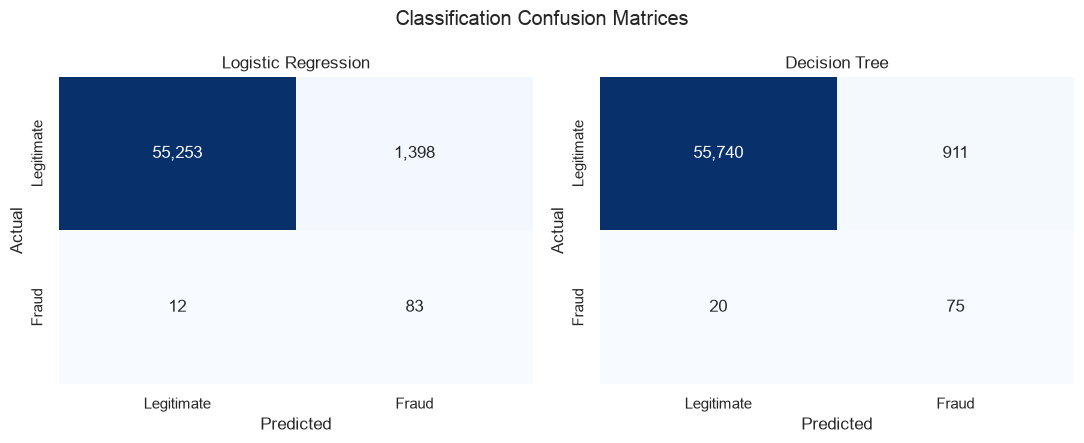

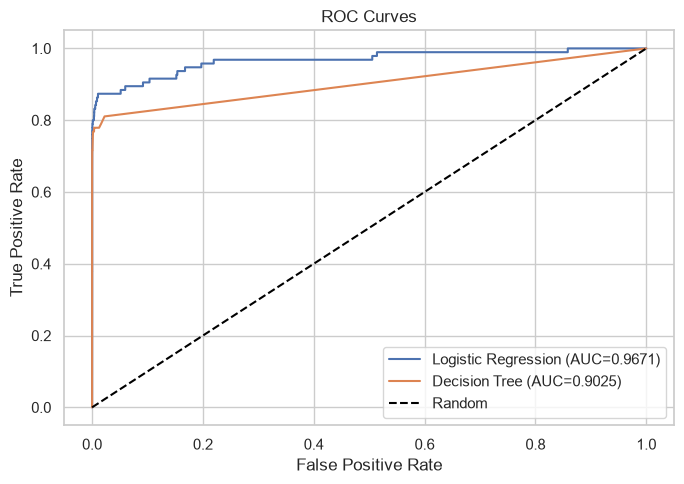

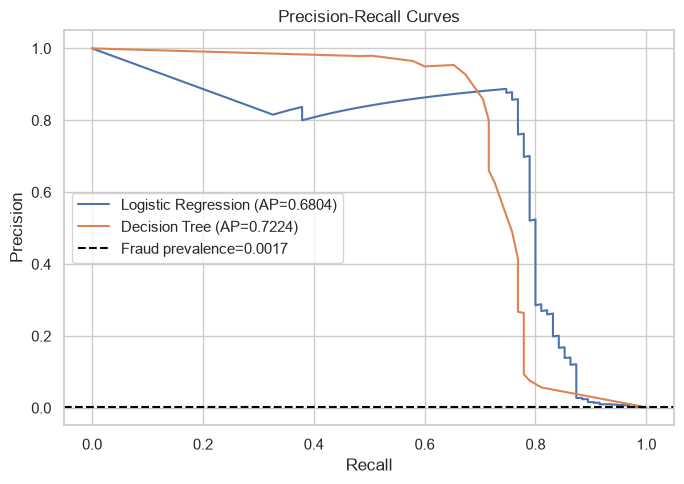

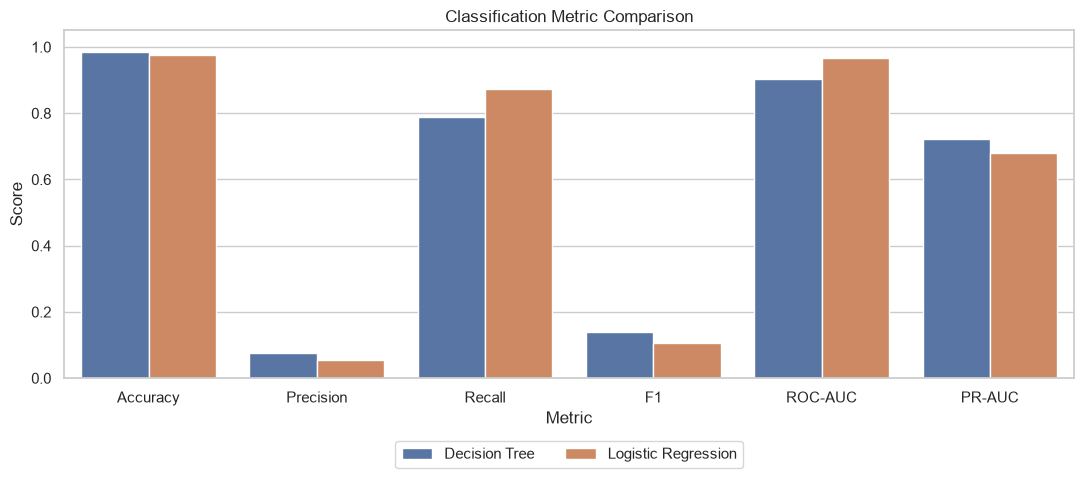

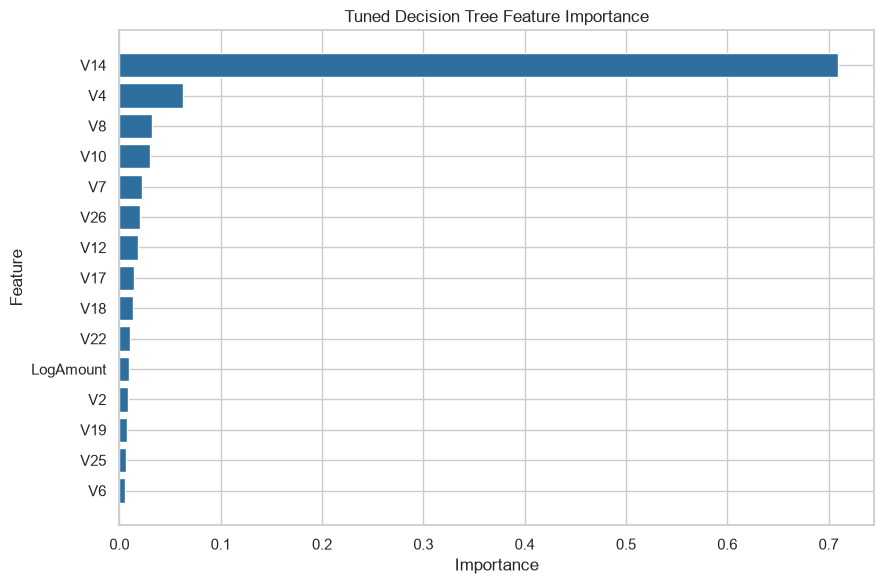

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for axis, (name, output) in zip(axes, classifier_outputs.items()):
    sns.heatmap(
        output["confusion_matrix"],
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        ax=axis,
        xticklabels=["Legitimate", "Fraud"],
        yticklabels=["Legitimate", "Fraud"],
    )
    axis.set(title=name, xlabel="Predicted", ylabel="Actual")
fig.suptitle("Classification Confusion Matrices")
save_figure("images/deliverable_3/01_confusion_matrices.png")

plt.figure(figsize=(7, 5))
for name, output in classifier_outputs.items():
    fpr, tpr, _ = roc_curve(y_test, output["probabilities"])
    auc_value = roc_auc_score(y_test, output["probabilities"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value:.4f})")
plt.plot([0, 1], [0, 1], color="black", linestyle="--", label="Random")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
save_figure("images/deliverable_3/02_roc_curves.png")

plt.figure(figsize=(7, 5))
baseline = y_test.mean()
for name, output in classifier_outputs.items():
    precision, recall, _ = precision_recall_curve(y_test, output["probabilities"])
    ap_value = average_precision_score(y_test, output["probabilities"])
    plt.plot(recall, precision, label=f"{name} (AP={ap_value:.4f})")
plt.axhline(baseline, color="black", linestyle="--", label=f"Fraud prevalence={baseline:.4f}")
plt.title("Precision-Recall Curves")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
save_figure("images/deliverable_3/03_precision_recall_curves.png")

comparison_long = classification_metrics.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"],
    var_name="Metric",
    value_name="Score",
)
plt.figure(figsize=(11, 5))
sns.barplot(data=comparison_long, x="Metric", y="Score", hue="Model")
plt.ylim(0, 1.05)
plt.title("Classification Metric Comparison")
plt.ylabel("Score")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
save_figure("images/deliverable_3/04_classification_metric_comparison.png")

importance_table = (
    pd.DataFrame({
        "Feature": classification_features,
        "Importance": tree_model.feature_importances_,
    })
    .sort_values("Importance", ascending=False)
    .head(15)
    .sort_values("Importance")
)
plt.figure(figsize=(9, 6))
plt.barh(importance_table["Feature"], importance_table["Importance"], color="#2f6f9f")
plt.title("Tuned Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
save_figure("images/deliverable_3/05_decision_tree_feature_importance.png")

**Interpretation:** ROC-AUC can look favorable under extreme imbalance because true negatives dominate. PR-AUC, fraud recall, precision, and the false-negative count provide the stronger basis for a screening recommendation.

## 5. K-Means Clustering

**Objective:** Explore transaction structure without using `Class`. A reproducible 50,000-row sample controls runtime, and all clustering features are standardized before fitting.

In [5]:
training_correlations = (
    pd.concat([X_train[PCA_COLUMNS], y_train.rename("Class")], axis=1)
    .corr(numeric_only=True)["Class"]
    .drop("Class")
)
selected_pca_features = (
    training_correlations.abs().sort_values(ascending=False).head(6).index.tolist()
)

clustering_features = [
    *PCA_COLUMNS,
    "LogAmount",
    "HourSin",
    "HourCos",
    "DayIndex",
]
cluster_sample = model_df.sample(
    n=min(50000, len(model_df)),
    random_state=RANDOM_STATE,
).copy()
cluster_scaler = StandardScaler()
cluster_scaled = cluster_scaler.fit_transform(cluster_sample[clustering_features])

clustering_rows = []
fitted_kmeans = {}
for k in range(2, 7):
    model = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = model.fit_predict(cluster_scaled)
    sizes = pd.Series(labels).value_counts()
    fitted_kmeans[k] = (model, labels)
    clustering_rows.append({
        "K": k,
        "Inertia": model.inertia_,
        "Silhouette Score": silhouette_score(
            cluster_scaled,
            labels,
            sample_size=min(5000, len(cluster_sample)),
            random_state=RANDOM_STATE,
        ),
        "Smallest Cluster": int(sizes.min()),
        "Largest Cluster": int(sizes.max()),
        "Smallest Cluster Percentage": sizes.min() / len(labels) * 100,
    })

clustering_metrics = pd.DataFrame(clustering_rows)
balanced_candidates = clustering_metrics[
    clustering_metrics["Smallest Cluster Percentage"].ge(5.0)
]
selected_k = int(
    balanced_candidates.sort_values(
        ["Silhouette Score", "Smallest Cluster Percentage"],
        ascending=False,
    ).iloc[0]["K"]
)
clustering_metrics["Selected"] = clustering_metrics["K"].eq(selected_k)
clustering_metrics.to_csv("results/clustering_metrics.csv", index=False)
display(clustering_metrics.style.format({
    "Inertia": "{:,.4f}",
    "Silhouette Score": "{:.4f}",
    "Smallest Cluster": "{:,.0f}",
    "Largest Cluster": "{:,.0f}",
    "Smallest Cluster Percentage": "{:.2f}%",
}))
print(f"Selected k: {selected_k}")
print("Focused PCA features:", ", ".join(selected_pca_features))

,K,Inertia,Silhouette Score,Smallest Cluster,Largest Cluster,Smallest Cluster Percentage,Selected
0,2,"1,522,509.4541",0.0654,"23,874","26,126",47.75%,False
1,3,"1,465,267.7251",0.0749,"3,487","24,241",6.97%,False
2,4,"1,425,186.0712",0.0762,"3,487","20,326",6.97%,True
3,5,"1,395,368.1208",0.0730,"3,487","17,943",6.97%,False
4,6,"1,355,485.8183",0.0872,500,"19,129",1.00%,False


Selected k: 4
Focused PCA features: V17, V14, V12, V10, V16, V3


**Interpretation:** Silhouette score measures separation and cohesion, while cluster sizes identify highly imbalanced solutions. Candidates with a smallest cluster below 5% are excluded from selection; the remaining candidate with the highest silhouette score is chosen. This is exploratory segmentation, not fraud detection.

## 6. Cluster Profiles and Visualizations

**Objective:** Reattach labels only after clustering, then compare transaction size, timing, selected feature means, and observed fraud concentration.

,Cluster,Transaction Count,Fraud Count,Fraud Rate,Median Amount,Mean Amount,Average Hour,Mean V17,Mean V14,Mean V12,Mean V10,Mean V16,Mean V3
0,0,"3,487",17,0.4875%,$15.58,$56.15,3.88,0.5178,1.2207,-2.3136,-0.3869,-0.0124,0.2995
1,1,"18,576",23,0.1238%,$17.76,$76.85,15.25,-0.1390,-0.0993,0.2802,-0.1086,-0.0759,-0.8158
2,2,"7,611",1,0.0131%,$46.98,$130.90,14.90,0.3229,-0.3580,-0.5288,0.7820,0.5200,0.0206
3,3,"20,326",36,0.1771%,$20.00,$86.42,15.62,-0.0773,-0.0037,0.3445,-0.1281,-0.1065,0.6970


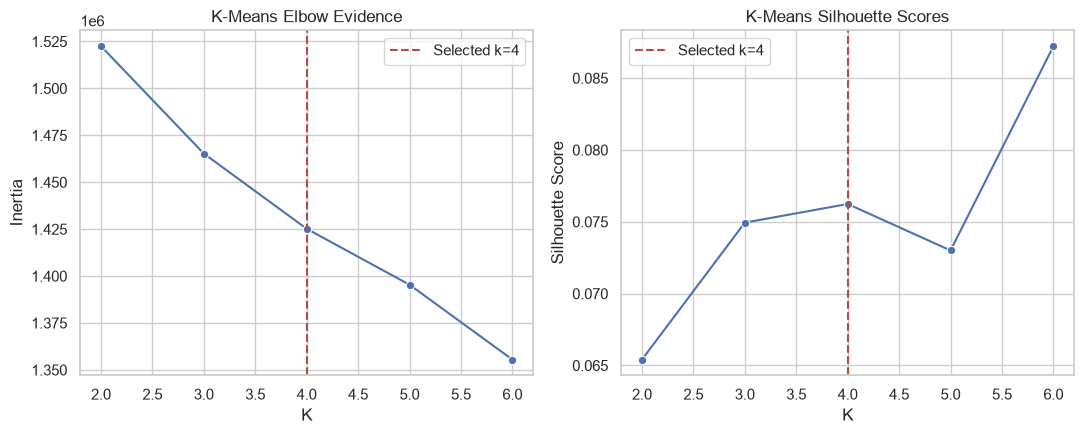

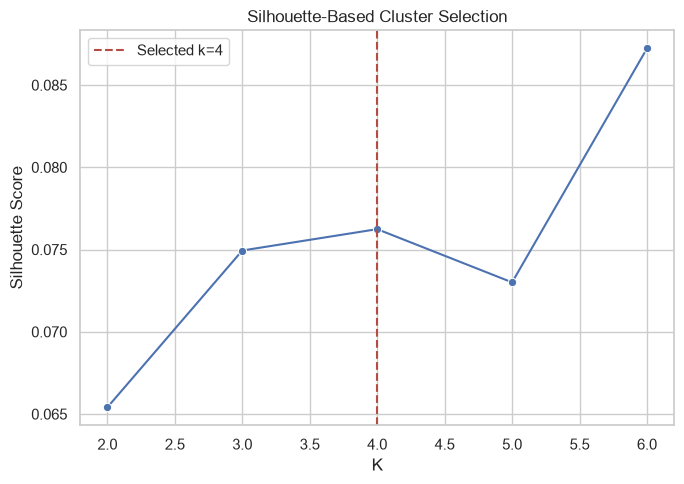

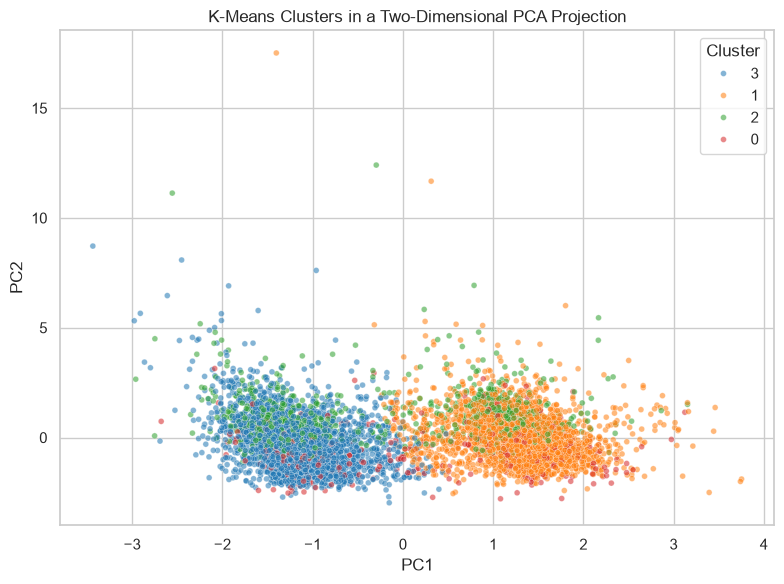

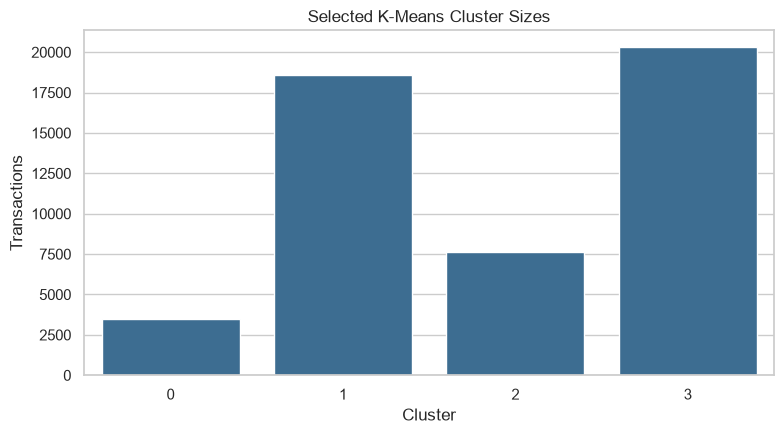

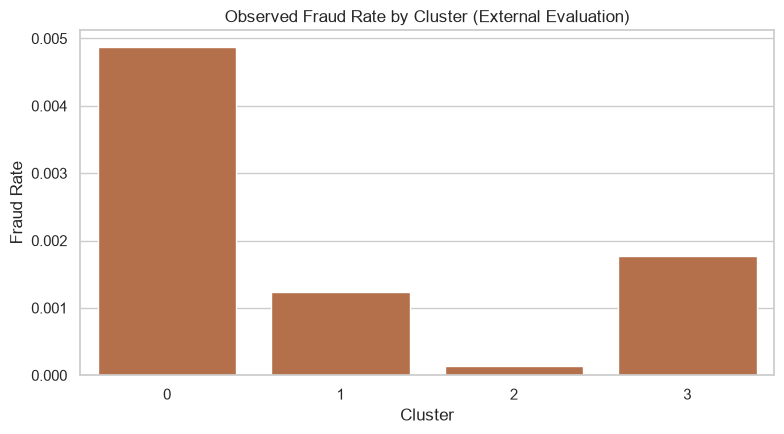

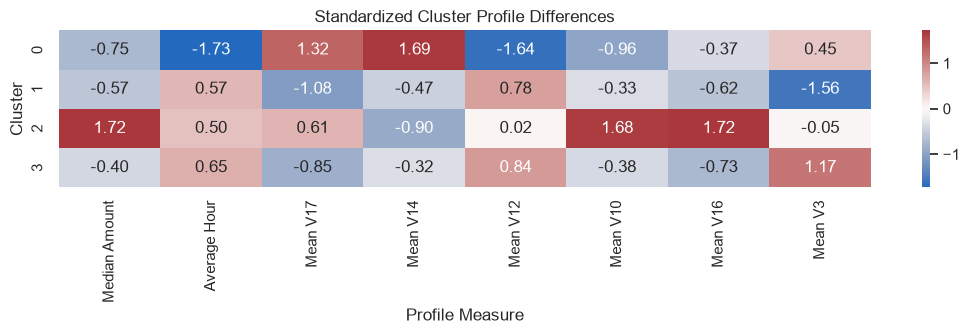

In [6]:
selected_model, selected_labels = fitted_kmeans[selected_k]
profiled_clusters = cluster_sample.copy()
profiled_clusters["Cluster"] = selected_labels

profile_aggregations = {
    "Transaction Count": ("Class", "size"),
    "Fraud Count": ("Class", "sum"),
    "Fraud Rate": ("Class", "mean"),
    "Median Amount": ("Amount", "median"),
    "Mean Amount": ("Amount", "mean"),
    "Average Hour": ("Hour", "mean"),
}
for feature in selected_pca_features:
    profile_aggregations[f"Mean {feature}"] = (feature, "mean")

cluster_profiles = (
    profiled_clusters.groupby("Cluster")
    .agg(**profile_aggregations)
    .reset_index()
)
cluster_profiles.to_csv("results/cluster_profiles.csv", index=False)
display(cluster_profiles.style.format({
    "Transaction Count": "{:,.0f}",
    "Fraud Count": "{:,.0f}",
    "Fraud Rate": "{:.4%}",
    "Median Amount": "${:,.2f}",
    "Mean Amount": "${:,.2f}",
    "Average Hour": "{:.2f}",
    **{f"Mean {feature}": "{:.4f}" for feature in selected_pca_features},
}))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sns.lineplot(data=clustering_metrics, x="K", y="Inertia", marker="o", ax=axes[0])
axes[0].axvline(selected_k, color="#b44c43", linestyle="--", label=f"Selected k={selected_k}")
axes[0].set_title("K-Means Elbow Evidence")
axes[0].legend()
sns.lineplot(
    data=clustering_metrics,
    x="K",
    y="Silhouette Score",
    marker="o",
    ax=axes[1],
)
axes[1].axvline(selected_k, color="#b44c43", linestyle="--", label=f"Selected k={selected_k}")
axes[1].set_title("K-Means Silhouette Scores")
axes[1].legend()
save_figure("images/deliverable_3/06_kmeans_elbow.png")

plt.figure(figsize=(7, 5))
sns.lineplot(data=clustering_metrics, x="K", y="Silhouette Score", marker="o")
plt.axvline(selected_k, color="#b44c43", linestyle="--", label=f"Selected k={selected_k}")
plt.title("Silhouette-Based Cluster Selection")
plt.legend()
save_figure("images/deliverable_3/07_kmeans_silhouette.png")

pca_projection = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(cluster_scaled)
projection_positions = (
    pd.Series(np.arange(len(cluster_sample)))
    .sample(n=min(6000, len(cluster_sample)), random_state=RANDOM_STATE)
    .to_numpy()
)
projection_df = pd.DataFrame({
    "PC1": pca_projection[projection_positions, 0],
    "PC2": pca_projection[projection_positions, 1],
    "Cluster": selected_labels[projection_positions].astype(str),
})
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=projection_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=18,
    alpha=0.55,
    palette="tab10",
)
plt.title("K-Means Clusters in a Two-Dimensional PCA Projection")
save_figure("images/deliverable_3/08_clusters_pca.png")

plt.figure(figsize=(8, 4.5))
sns.barplot(data=cluster_profiles, x="Cluster", y="Transaction Count", color="#2f6f9f")
plt.title("Selected K-Means Cluster Sizes")
plt.ylabel("Transactions")
save_figure("images/deliverable_3/09_cluster_sizes.png")

plt.figure(figsize=(8, 4.5))
sns.barplot(data=cluster_profiles, x="Cluster", y="Fraud Rate", color="#c56a3a")
plt.title("Observed Fraud Rate by Cluster (External Evaluation)")
plt.ylabel("Fraud Rate")
save_figure("images/deliverable_3/10_fraud_rate_by_cluster.png")

heatmap_columns = ["Median Amount", "Average Hour", *[f"Mean {f}" for f in selected_pca_features]]
heatmap_values = cluster_profiles.set_index("Cluster")[heatmap_columns]
heatmap_standardized = (
    heatmap_values - heatmap_values.mean()
) / heatmap_values.std(ddof=0).replace(0, 1)
plt.figure(figsize=(11, max(3.5, selected_k * 0.7)))
sns.heatmap(heatmap_standardized, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Standardized Cluster Profile Differences")
plt.xlabel("Profile Measure")
save_figure("images/deliverable_3/11_cluster_profile_heatmap.png")

**Interpretation:** Labels were excluded from model fitting. If one cluster has a higher observed fraud concentration, that result describes external composition only; it does not show that K-Means independently detects fraud.

## 7. Association Rule Mining with FP-Growth

**Objective:** Convert continuous training observations into categorical conditions, then mine interpretable rules whose consequent is exactly `Class_Fraud`. The enriched sample contains all training fraud rows and five reproducibly sampled legitimate rows per fraud row.

Support from this enriched sample does **not** estimate population prevalence.

In [7]:
training_source = model_df.loc[X_train.index].copy()
fraud_training = training_source[training_source["Class"] == 1]
legitimate_training = training_source[training_source["Class"] == 0].sample(
    n=min(len(fraud_training) * 5, (training_source["Class"] == 0).sum()),
    random_state=RANDOM_STATE,
)
association_sample = pd.concat(
    [fraud_training, legitimate_training],
    ignore_index=True,
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

def training_quantile_bins(series, quantiles):
    edges = np.unique(series.quantile(quantiles).to_numpy(dtype=float))
    if len(edges) < 2:
        raise ValueError(f"Insufficient unique quantile edges for {series.name}.")
    edges[0], edges[-1] = -np.inf, np.inf
    return edges

discretized = pd.DataFrame(index=association_sample.index)
amount_edges = training_quantile_bins(
    training_source["Amount"],
    [0.0, 0.50, 0.90, 1.0],
)
discretized["Amount Category"] = pd.cut(
    association_sample["Amount"],
    bins=amount_edges,
    labels=["Amount_Low", "Amount_Medium", "Amount_High"][: len(amount_edges) - 1],
    include_lowest=True,
)
discretized["Time Category"] = pd.cut(
    association_sample["Hour"],
    bins=[0, 6, 12, 18, 24],
    labels=["Time_Night", "Time_Morning", "Time_Afternoon", "Time_Evening"],
    include_lowest=True,
    right=False,
)

level_names = ["Low", "Middle", "High"]
for feature in selected_pca_features:
    edges = training_quantile_bins(
        training_source[feature],
        [0.0, 1 / 3, 2 / 3, 1.0],
    )
    discretized[f"{feature} Category"] = pd.cut(
        association_sample[feature],
        bins=edges,
        labels=[f"{feature}_{level}" for level in level_names[: len(edges) - 1]],
        include_lowest=True,
    )

item_matrix = pd.get_dummies(discretized, dtype=bool)
item_matrix.columns = [column.split("_", 1)[-1] for column in item_matrix.columns]
item_matrix["Class_Fraud"] = association_sample["Class"].eq(1)
item_matrix["Class_Legitimate"] = association_sample["Class"].eq(0)

threshold_rows = []
rules_by_support = {}
for minimum_support in [0.02, 0.03, 0.05]:
    frequent_itemsets = fpgrowth(
        item_matrix,
        min_support=minimum_support,
        use_colnames=True,
    )
    candidate_rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=0.60,
    )
    fraud_rules = candidate_rules[
        candidate_rules["consequents"].eq(frozenset({"Class_Fraud"}))
        & candidate_rules["lift"].ge(1.20)
    ].copy()
    rules_by_support[minimum_support] = fraud_rules
    threshold_rows.append({
        "Minimum Support": minimum_support,
        "Fraud Rules": len(fraud_rules),
    })

threshold_sensitivity = pd.DataFrame(threshold_rows)
final_minimum_support = 0.03 if len(rules_by_support[0.03]) else 0.02
selected_rules = rules_by_support[final_minimum_support].sort_values(
    ["lift", "confidence", "support"],
    ascending=False,
)

def itemset_text(itemset):
    return " AND ".join(sorted(itemset))

association_rules_export = pd.DataFrame({
    "Antecedents": selected_rules["antecedents"].map(itemset_text),
    "Consequent": selected_rules["consequents"].map(itemset_text),
    "Support": selected_rules["support"],
    "Confidence": selected_rules["confidence"],
    "Lift": selected_rules["lift"],
    "Leverage": selected_rules["leverage"],
    "Conviction": selected_rules["conviction"],
    "Minimum Support": final_minimum_support,
    "Enriched Sample Rows": len(association_sample),
    "Fraud Rows": len(fraud_training),
    "Legitimate Rows": len(legitimate_training),
}).reset_index(drop=True)
association_rules_export.to_csv("results/association_rules.csv", index=False)

print("Selected PCA features:", ", ".join(selected_pca_features))
print(
    f"Association sample: {len(fraud_training):,} fraud + "
    f"{len(legitimate_training):,} legitimate rows"
)
print(f"Selected minimum support: {final_minimum_support:.2f}")
display(threshold_sensitivity)
display(association_rules_export.head(10).style.format({
    "Support": "{:.4f}",
    "Confidence": "{:.4f}",
    "Lift": "{:.4f}",
    "Leverage": "{:.4f}",
    "Conviction": "{:.4f}",
    "Minimum Support": "{:.2f}",
    "Enriched Sample Rows": "{:,.0f}",
    "Fraud Rows": "{:,.0f}",
    "Legitimate Rows": "{:,.0f}",
}))

Selected PCA features: V17, V14, V12, V10, V16, V3
Association sample: 378 fraud + 1,890 legitimate rows
Selected minimum support: 0.03


,Minimum Support,Fraud Rules
0,0.0200,512
1,0.0300,319
2,0.0500,108


,Antecedents,Consequent,Support,Confidence,Lift,Leverage,Conviction,Minimum Support,Enriched Sample Rows,Fraud Rows,Legitimate Rows
0,V10_Low AND V12_Low AND V14_Low AND V16_Low AND V3_Low,Class_Fraud,0.1287,1.0000,6.0000,0.1073,inf,0.03,"2,268",378,"1,890"
1,V10_Low AND V12_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.1257,1.0000,6.0000,0.1047,inf,0.03,"2,268",378,"1,890"
2,V10_Low AND V14_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.1248,1.0000,6.0000,0.1040,inf,0.03,"2,268",378,"1,890"
3,V10_Low AND V12_Low AND V14_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.1248,1.0000,6.0000,0.1040,inf,0.03,"2,268",378,"1,890"
4,Amount_Low AND V10_Low AND V12_Low AND V14_Low AND V16_Low AND V3_Low,Class_Fraud,0.0697,1.0000,6.0000,0.0581,inf,0.03,"2,268",378,"1,890"
5,Amount_Low AND V10_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.0670,1.0000,6.0000,0.0558,inf,0.03,"2,268",378,"1,890"
6,Amount_Low AND V10_Low AND V12_Low AND V17_Low AND V3_Low,Class_Fraud,0.0670,1.0000,6.0000,0.0558,inf,0.03,"2,268",378,"1,890"
7,Amount_Low AND V10_Low AND V12_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.0670,1.0000,6.0000,0.0558,inf,0.03,"2,268",378,"1,890"
8,Amount_Low AND V10_Low AND V14_Low AND V16_Low AND V17_Low AND V3_Low,Class_Fraud,0.0661,1.0000,6.0000,0.0551,inf,0.03,"2,268",378,"1,890"
9,Amount_Low AND V10_Low AND V12_Low AND V14_Low AND V17_Low AND V3_Low,Class_Fraud,0.0661,1.0000,6.0000,0.0551,inf,0.03,"2,268",378,"1,890"


## 8. Association Rule Visualizations

**Objective:** Present support-confidence tradeoffs and the strongest fraud-associated patterns without overcrowding labels.

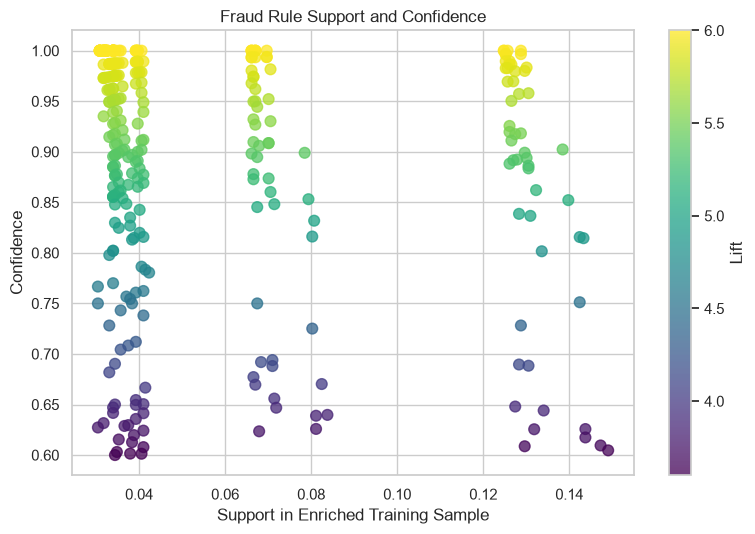

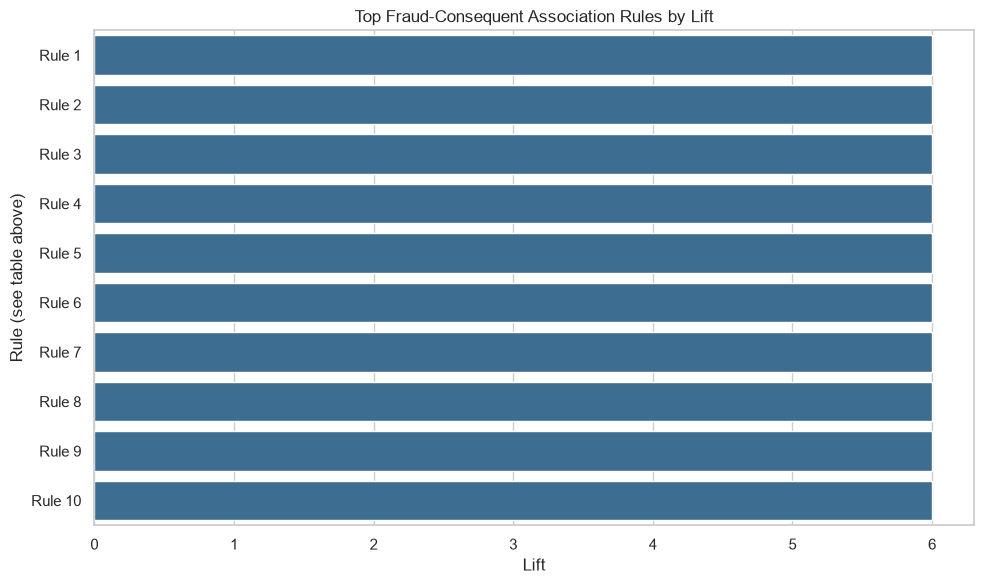

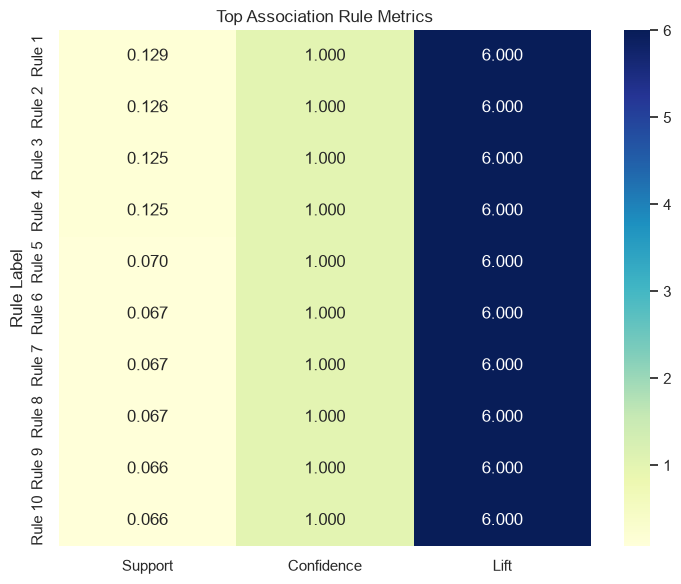

In [8]:
if association_rules_export.empty:
    raise RuntimeError("No fraud-consequent rules met the documented sensitivity thresholds.")

top_rules = association_rules_export.head(10).copy()
top_rules["Rule Label"] = [
    f"Rule {index + 1}" for index in range(len(top_rules))
]

plt.figure(figsize=(8, 5.5))
scatter = plt.scatter(
    association_rules_export["Support"],
    association_rules_export["Confidence"],
    c=association_rules_export["Lift"],
    s=60,
    cmap="viridis",
    alpha=0.75,
)
plt.colorbar(scatter, label="Lift")
plt.title("Fraud Rule Support and Confidence")
plt.xlabel("Support in Enriched Training Sample")
plt.ylabel("Confidence")
save_figure("images/deliverable_3/12_rule_support_confidence.png")

plt.figure(figsize=(10, 6))
sns.barplot(data=top_rules, x="Lift", y="Rule Label", color="#2f6f9f")
plt.title("Top Fraud-Consequent Association Rules by Lift")
plt.xlabel("Lift")
plt.ylabel("Rule (see table above)")
save_figure("images/deliverable_3/13_top_rules_by_lift.png")

rule_heatmap = top_rules.set_index("Rule Label")[["Support", "Confidence", "Lift"]]
plt.figure(figsize=(7.5, 6))
sns.heatmap(rule_heatmap, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Top Association Rule Metrics")
save_figure("images/deliverable_3/14_rule_metric_heatmap.png")

## 9. Final Interpretation and Recommendations

**Objective:** Select the classification model using rare-class evidence, summarize cluster composition cautiously, and identify representative rules without overstating causality.

In [9]:
recommended_classifier = classification_metrics.sort_values(
    ["PR-AUC", "Recall", "F1"],
    ascending=False,
).iloc[0]
highest_fraud_cluster = cluster_profiles.loc[cluster_profiles["Fraud Rate"].idxmax()]

print(
    f"Classification recommendation: {recommended_classifier['Model']} "
    f"(PR-AUC={recommended_classifier['PR-AUC']:.4f}, "
    f"Recall={recommended_classifier['Recall']:.4f}, "
    f"Precision={recommended_classifier['Precision']:.4f}, "
    f"False Negatives={int(recommended_classifier['False Negatives'])})."
)
print(
    f"K-Means selected k={selected_k}. Cluster "
    f"{int(highest_fraud_cluster['Cluster'])} had the highest observed fraud "
    f"concentration ({highest_fraud_cluster['Fraud Rate']:.4%}) in the clustering sample."
)
print(
    f"FP-Growth retained {len(association_rules_export):,} fraud-consequent rules. "
    f"The top displayed rule had lift={top_rules.iloc[0]['Lift']:.4f} and "
    f"confidence={top_rules.iloc[0]['Confidence']:.4f}."
)

Classification recommendation: Decision Tree (PR-AUC=0.7224, Recall=0.7895, Precision=0.0761, False Negatives=20).
K-Means selected k=4. Cluster 0 had the highest observed fraud concentration (0.4875%) in the clustering sample.
FP-Growth retained 319 fraud-consequent rules. The top displayed rule had lift=6.0000 and confidence=1.0000.


### Practical Relevance, Challenges, and Limits

- The recommended classifier may support a human-reviewed screening queue; threshold selection should reflect the costs of false positives and false negatives.
- Accuracy is not sufficient evidence because legitimate transactions dominate the data.
- One cluster had a higher observed fraud concentration, but cluster assignment is exploratory segmentation rather than a fraud prediction.
- FP-Growth rules identify conditions associated with fraud in an enriched training sample. Their support does not represent original prevalence, and the rules do not establish causation or replace the classifier.
- Protected demographic attributes are unavailable, so demographic fairness cannot be evaluated.
- Fraud behavior can change over time; deployed performance would require drift monitoring, periodic retraining, audit logs, and human oversight.

**Connection to Deliverable 4:** The final deliverable consolidates the validated data, regression, classification, clustering, and association findings into synchronized recommendations, a written report, and a presentation.